# Task 1A — Exploratory Data Analysis

I'm forecasting hourly electricity demand for **PJM East (PJME)**. The target is
`PJME_MW`, the megawatts consumed each hour. Before building any features or a model
I want to understand the series: how long it runs, how often it's sampled, whether
any hours are missing, and how demand is distributed.


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_series, make_hourly

sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "outputs" / "figures"

raw = load_series("PJME")
raw.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## Time range and granularity

In [2]:
print("First reading:", raw.index.min())
print("Last reading: ", raw.index.max())
print("Total readings:", len(raw))
print("Span:", raw.index.max() - raw.index.min())

# how far apart are consecutive rows? this tells me the real granularity
print("\nSpacing between consecutive rows:")
print(raw.index.to_series().diff().value_counts().head())

First reading: 2002-01-01 01:00:00
Last reading:  2018-08-03 00:00:00
Total readings: 145362
Span: 6057 days 23:00:00

Spacing between consecutive rows:
Datetime
0 days 01:00:00    145331
0 days 02:00:00        30
Name: count, dtype: int64


The data runs from **2002 to 2018** and almost every row is exactly one hour apart,
so this is a clean hourly series. The few odd gaps are the daylight-saving switches,
which I deal with next.


## Missing values

In [3]:
expected = len(pd.date_range(raw.index.min(), raw.index.max(), freq="h"))
print("Hours on a full hourly grid:", expected)
print("Hours actually in the file: ", len(raw))
print("Missing hours:              ", expected - len(raw))

df = make_hourly(raw)   # reindex to the full grid + time interpolation
print("NaNs left after interpolation:", int(df["PJME_MW"].isna().sum()))

Hours on a full hourly grid: 145392
Hours actually in the file:  145362
Missing hours:               30
NaNs left after interpolation: 0


Only **30 hours** are missing out of ~145k — well under 0.03% of the data. I fill
them with time-based interpolation rather than dropping them, because the gaps are
single isolated hours and load changes smoothly from one hour to the next, so a
straight line between the neighbours is a safe estimate. Dropping rows would also
break the fixed hourly spacing that the lag features rely on.


## Distribution of demand

count    145392.0
mean      32078.9
std        6464.3
min       14544.0
25%       27571.0
50%       31420.0
75%       35647.0
max       62009.0
Name: PJME_MW, dtype: float64


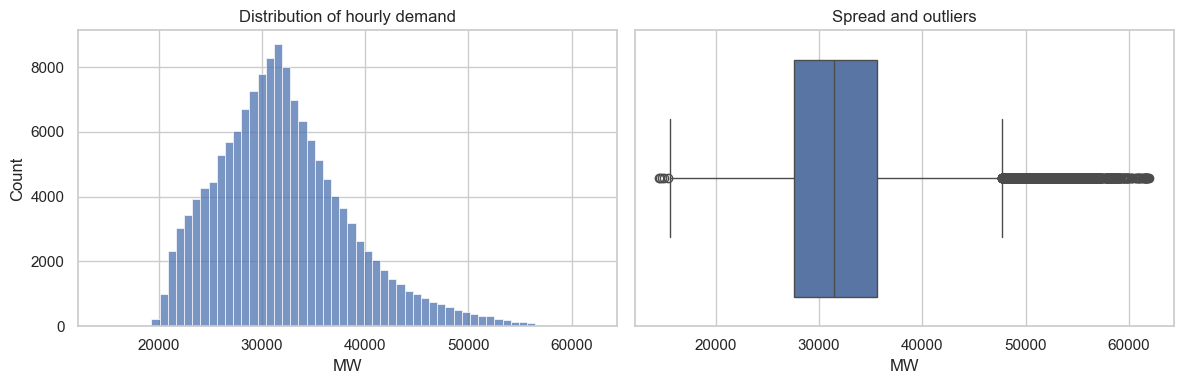

In [4]:
print(df["PJME_MW"].describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["PJME_MW"], bins=60, ax=ax[0])
ax[0].set(title="Distribution of hourly demand", xlabel="MW")
sns.boxplot(x=df["PJME_MW"], ax=ax[1])
ax[1].set(title="Spread and outliers", xlabel="MW")
fig.tight_layout()
fig.savefig(FIG / "eda_distribution.png", dpi=120)
plt.show()

Demand sits around a mean of ~32,000 MW but the distribution is right-skewed: most
hours are moderate, with a long tail of high-demand hours. Those are the summer and
winter peaks when heating and cooling load spikes. There are no impossible values
(no negatives, no zeros), so I don't treat the tail as outliers to remove — it's real
peak demand the model should learn.


## The series over time

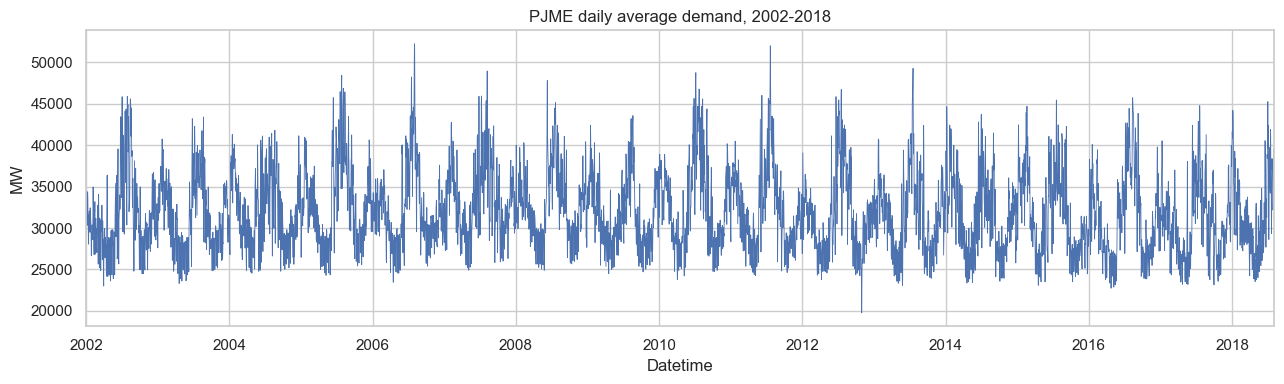

In [5]:
daily = df["PJME_MW"].resample("D").mean()
fig, ax = plt.subplots(figsize=(13, 4))
daily.plot(ax=ax, lw=0.6)
ax.set(title="PJME daily average demand, 2002-2018", ylabel="MW")
fig.tight_layout()
fig.savefig(FIG / "eda_timeline.png", dpi=120)
plt.show()

The daily average makes the **yearly cycle** obvious — every year has twin peaks
(summer cooling and winter heating) with milder spring/autumn dips. The overall level
is fairly flat across the years, so this is dominated by seasonality rather than a
strong long-term trend (I test that properly in the next notebook).


## Seasonal profiles

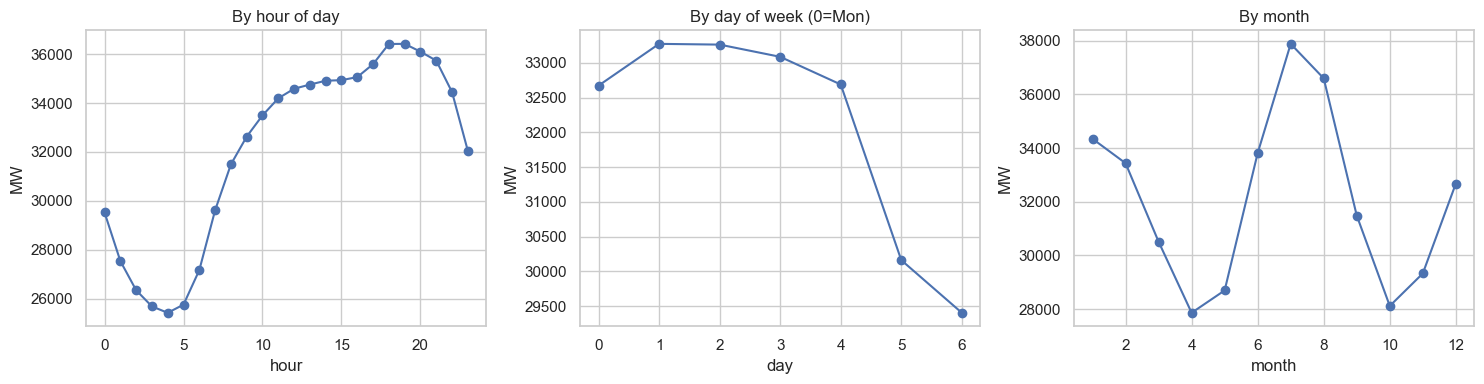

In [6]:
prof = pd.DataFrame({"MW": df["PJME_MW"]})
prof["hour"] = prof.index.hour
prof["dow"] = prof.index.dayofweek
prof["month"] = prof.index.month

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
prof.groupby("hour")["MW"].mean().plot(ax=ax[0], marker="o")
ax[0].set(title="By hour of day", xlabel="hour", ylabel="MW")
prof.groupby("dow")["MW"].mean().plot(ax=ax[1], marker="o")
ax[1].set(title="By day of week (0=Mon)", xlabel="day", ylabel="MW")
prof.groupby("month")["MW"].mean().plot(ax=ax[2], marker="o")
ax[2].set(title="By month", xlabel="month", ylabel="MW")
fig.tight_layout()
fig.savefig(FIG / "eda_seasonal.png", dpi=120)
plt.show()

Three cycles stand out:
- **Hour:** demand dips overnight, climbs through the morning and peaks in the early
  evening.
- **Day of week:** weekdays are clearly higher than weekends.
- **Month:** July/August (cooling) and January (heating) are the heaviest months.

These are exactly the patterns the lag and moving-average features are meant to
capture, which motivates the analytical questions and feature choices that follow.


## Summary

- Clean **hourly** series, **2002-2018**, ~145k readings.
- Only **30 missing hours**, filled with time interpolation to keep the grid regular.
- Demand is right-skewed around ~32,000 MW with a real peak-demand tail.
- Strong **daily, weekly and yearly** seasonality — the basis for the features I build next.
